Rohith John 24BAD100
--- Data Inspection ---
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

--- Top 5 Recommendations for User 1 ---
item_id
318    2.035432
423    1.871222
357    1.792122
286    1.742431
288    1.696068
Name: 1, dtype: float64

--- Evaluation Metrics ---
RMSE: 2.8006
MAE: 2.5782


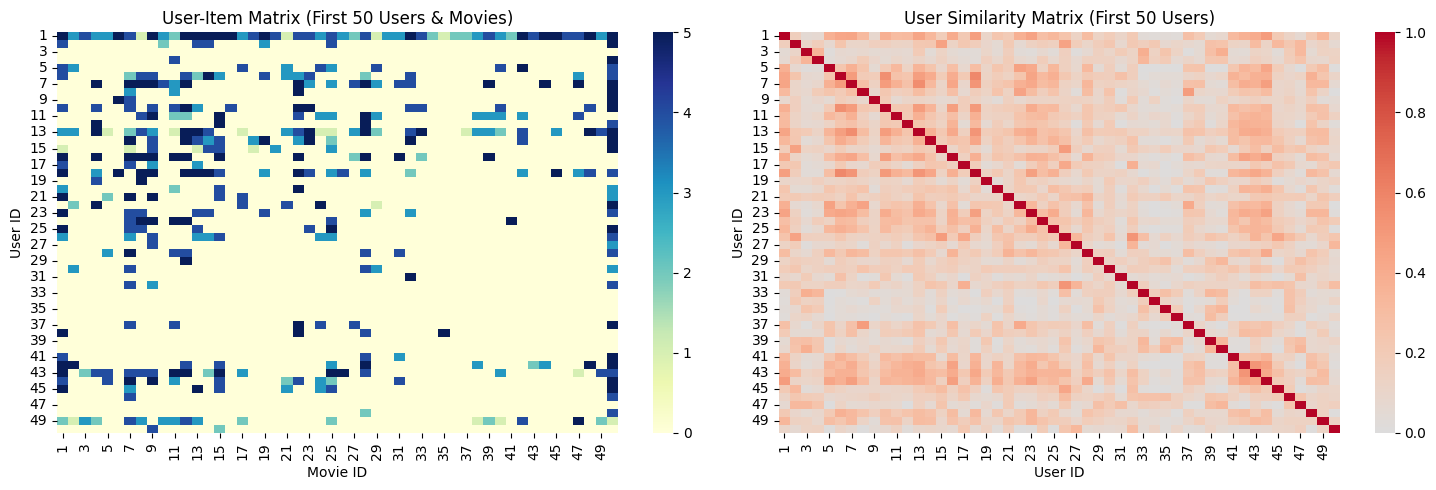

In [2]:
# 1. Import required Python libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Rohith John 24BAD100")
# 2. Load the MovieLens dataset
url = 'http://files.grouplens.org/datasets/movielens/ml-100k/u.data'
columns = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv(url, sep='\t', names=columns)

# 3. Perform data inspection & preprocessing
print("--- Data Inspection ---")
print(df.head())
print("\nDataset Info:")
print(df.info())
# Drop timestamp as it's not needed for basic KNN collaborative filtering
df = df.drop('timestamp', axis=1)

# 4. Create User-Item matrix
# Rows = Users, Columns = Movies, Values = Ratings
user_item_matrix = df.pivot_table(index='user_id', columns='item_id', values='rating')

# 5. Handle missing values (fill with 0)
# Filling with 0 assumes an unrated movie is a "0".
# (Mean centering is an alternative, but 0 is standard for basic Cosine Similarity)
user_item_matrix_filled = user_item_matrix.fillna(0)

# 6. Compute similarity between users (Cosine similarity)
# Calculate cosine similarity between all users
user_similarity = cosine_similarity(user_item_matrix_filled)
user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_item_matrix.index,
                                  columns=user_item_matrix.index)

# 7. Identify top-N similar users (Helper Function)
def get_top_n_similar_users(user_id, n=5):
    # Sort similarity scores for the given user in descending order (excluding the user themselves)
    similar_users = user_similarity_df[user_id].sort_values(ascending=False).drop(user_id)
    return similar_users.head(n)

# 8. Predict ratings for unseen movies
# Formula: Predicted_Rating = (User_Similarity_Matrix dot User_Item_Matrix) / Sum_of_Similarities
# We add a small epsilon (1e-9) to avoid division by zero
sum_of_similarities = np.array([np.abs(user_similarity).sum(axis=1)]).T + 1e-9
predicted_ratings = user_similarity.dot(user_item_matrix_filled.values) / sum_of_similarities

predicted_ratings_df = pd.DataFrame(predicted_ratings,
                                    index=user_item_matrix.index,
                                    columns=user_item_matrix.columns)
#Rohith John 24BAD100
# 9. Generate Top-N recommendations for a user
def recommend_movies(user_id, num_recommendations=5):
    # Get movies the user has already rated
    user_rated_movies = user_item_matrix.loc[user_id].dropna().index

    # Get all predicted ratings for this user
    user_predictions = predicted_ratings_df.loc[user_id]

    # Filter out movies the user has already seen
    unseen_predictions = user_predictions.drop(user_rated_movies, errors='ignore')

    # Sort by highest predicted rating
    top_recommendations = unseen_predictions.sort_values(ascending=False).head(num_recommendations)
    return top_recommendations

# Example usage:
sample_user = 1
print(f"\n--- Top 5 Recommendations for User {sample_user} ---")
print(recommend_movies(sample_user, 5))

# 10. Evaluate using RMSE and MAE
# To evaluate, we only look at the ratings that actually exist (non-zero in the original matrix)
actual_ratings = user_item_matrix_filled.values.flatten()
pred_ratings = predicted_ratings_df.values.flatten()

# Filter out the 0s (missing values) to only evaluate on known ratings
mask = actual_ratings > 0
actual_known = actual_ratings[mask]
pred_known = pred_ratings[mask]
rmse = np.sqrt(mean_squared_error(actual_known, pred_known))
mae = mean_absolute_error(actual_known, pred_known)

print(f"\n--- Evaluation Metrics ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# Visualizations
plt.figure(figsize=(15, 5))

# Visualization 1: Heatmap of User-Item Matrix (Subset to avoid crashing)
plt.subplot(1, 2, 1)
# Slicing the first 50 users and 50 movies so it renders cleanly
sns.heatmap(user_item_matrix_filled.iloc[:50, :50], cmap="YlGnBu", cbar=True)
plt.title("User-Item Matrix (First 50 Users & Movies)")
plt.xlabel("Movie ID")
plt.ylabel("User ID")

# Visualization 2: Similarity Matrix Heatmap (Subset)
plt.subplot(1, 2, 2)
sns.heatmap(user_similarity_df.iloc[:50, :50], cmap="coolwarm", center=0)
plt.title("User Similarity Matrix (First 50 Users)")
plt.xlabel("User ID")
plt.ylabel("User ID")

plt.tight_layout()
plt.show()